<a href="https://colab.research.google.com/github/Krishna-Dhawangale/Resume-Screening-Machine-Learning-/blob/main/Naive_Bayes_resume_screening.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML_Data/AI_Resume_Screening.csv')
df.head(20)

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100
5,6,Samantha Santos,"Cybersecurity, Networking, Linux, Ethical Hacking",10,B.Tech,Google ML,Cybersecurity Analyst,Hire,47957,5,100
6,7,Tony Smith,"Networking, Cybersecurity, Ethical Hacking",4,M.Tech,AWS Certified,Cybersecurity Analyst,Hire,66208,9,100
7,8,Anthony Harrison,"TensorFlow, Pytorch, NLP",3,M.Tech,AWS Certified,AI Researcher,Hire,103006,7,90
8,9,Nancy Jenkins,"Networking, Ethical Hacking",7,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,92270,3,100
9,10,Courtney Gibson,"Python, TensorFlow, Pytorch, NLP",0,M.Tech,AWS Certified,AI Researcher,Reject,60579,1,35


In [4]:
print("Dataset Head:")
display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nClass Distribution (Job Role):")
print(df['Job Role'].value_counts())

Dataset Head:


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100



Dataset Shape:
(1000, 11)

Column Names:
['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education', 'Certifications', 'Job Role', 'Recruiter Decision', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']

Missing Values:
Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64

Class Distribution (Job Role):
Job Role
AI Researcher            257
Data Scientist           255
Cybersecurity Analyst    255
Software Engineer        233
Name: count, dtype: int64


In [6]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import LabelEncoder

# Download NLTK data (if not already downloaded)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab') # Added to fix LookupError

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove punctuation and special characters
    tokens = nltk.word_tokenize(text) # Tokenization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] # Lemmatization and stopword removal
    return ' '.join(tokens)

# Apply text cleaning to the 'Skills' column
df['Cleaned_Skills'] = df['Skills'].apply(clean_text)

# Encode target labels
label_encoder = LabelEncoder()
df['Job_Role_Encoded'] = label_encoder.fit_transform(df['Job Role'])

print("Original Skills vs Cleaned Skills (first 5 rows):")
display(df[['Skills', 'Cleaned_Skills', 'Job Role', 'Job_Role_Encoded']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Original Skills vs Cleaned Skills (first 5 rows):


,Skills,Cleaned_Skills,Job Role,Job_Role_Encoded
0,"TensorFlow, NLP, Pytorch",tensorflow nlp pytorch,AI Researcher,0
1,"Deep Learning, Machine Learning, Python, SQL",deep learning machine learning python sql,Data Scientist,2
2,"Ethical Hacking, Cybersecurity, Linux",ethical hacking cybersecurity linux,Cybersecurity Analyst,1
3,"Python, Pytorch, TensorFlow",python pytorch tensorflow,AI Researcher,0
4,"SQL, React, Java",sql react java,Software Engineer,3



--- Model Evaluation ---
Accuracy: 1.0000

Classification Report:
                       precision    recall  f1-score   support

        AI Researcher       1.00      1.00      1.00        51
Cybersecurity Analyst       1.00      1.00      1.00        51
       Data Scientist       1.00      1.00      1.00        51
    Software Engineer       1.00      1.00      1.00        47

             accuracy                           1.00       200
            macro avg       1.00      1.00      1.00       200
         weighted avg       1.00      1.00      1.00       200


Confusion Matrix:


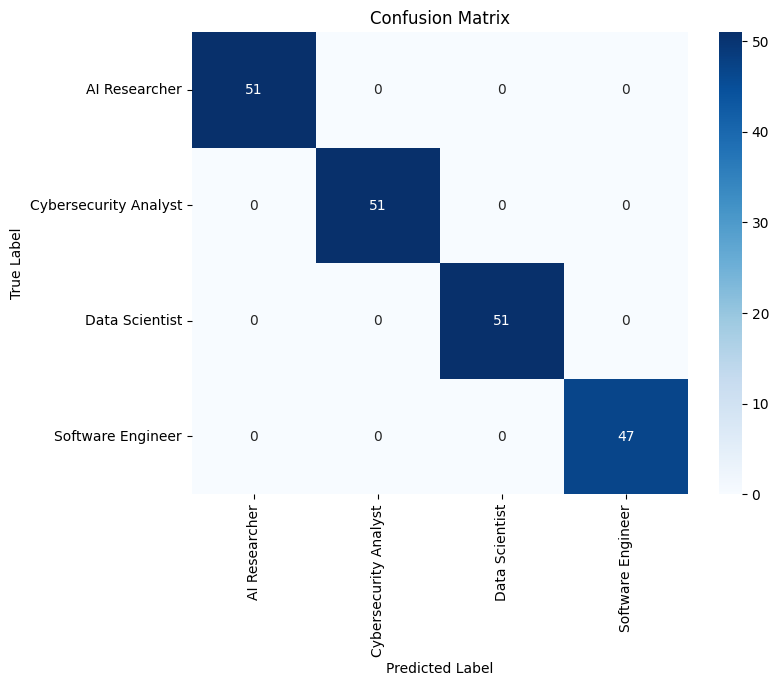

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Make predictions on the test data
y_pred = model.predict(X_test)

print("\n--- Model Evaluation ---")

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Generate Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [9]:
from sklearn.naive_bayes import MultinomialNB

# Initialize and train the Multinomial Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


In [8]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, df['Job_Role_Encoded'], test_size=0.2, random_state=42, stratify=df['Job_Role_Encoded'])

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (800, 58)
Shape of X_test: (200, 58)
Shape of y_train: (800,)
Shape of y_test: (200,)


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

# Fit and transform the 'Cleaned_Skills' column
X = tfidf_vectorizer.fit_transform(df['Cleaned_Skills'])

print("Shape of TF-IDF features:", X.shape)
print("First 5 rows of TF-IDF features (sample, as it's sparse matrix):")
# Convert to dense array for display, but note that it's usually sparse
display(pd.DataFrame(X[:5].toarray(), columns=tfidf_vectorizer.get_feature_names_out()))

Shape of TF-IDF features: (1000, 58)
First 5 rows of TF-IDF features (sample, as it's sparse matrix):


,cybersecurity,cybersecurity ethical,cybersecurity linux,cybersecurity networking,deep,deep learning,ethical,ethical hacking,hacking,hacking cybersecurity,...,sql,sql deep,sql java,sql machine,sql python,sql react,tensorflow,tensorflow nlp,tensorflow python,tensorflow pytorch
0,0.00000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.358083,0.533933,0.0,0.0
1,0.00000,0.0,0.000000,0.0,0.262157,0.262157,0.000000,0.000000,0.000000,0.000000,...,0.194302,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
2,0.31666,0.0,0.516192,0.0,0.000000,0.000000,0.303425,0.303425,0.303425,0.509459,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0
3,0.00000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.0,0.0,0.0,0.000000,0.360611,0.000000,0.0,0.0
4,0.00000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.263621,0.0,0.0,0.0,0.0,0.600849,0.000000,0.000000,0.0,0.0
